<a href="https://colab.research.google.com/github/asifmanowar9/Neural-network-project/blob/main/DDoS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df_dataset = pd.read_csv("/content/drive/MyDrive/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

In [ ]:
df_dataset

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225740,61374,61,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225741,61378,72,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225742,61375,75,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
225743,61323,48,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


### Step 1: Data Cleaning
We will clean column names, handle infinite values (which are common in network flow data), and remove any missing values.

In [ ]:
import numpy as np

# 1. Strip whitespace from column names
df_dataset.columns = df_dataset.columns.str.strip()

# 2. Replace infinite values with NaN
df_dataset.replace([np.inf, -np.inf], np.nan, inplace=True)

# 3. Check for missing values
missing_count = df_dataset.isnull().sum().sum()
print(f'Total missing values after replacing inf: {missing_count}')

# 4. Drop rows with missing values
df_dataset.dropna(inplace=True)

print(f'Dataset shape after cleaning: {df_dataset.shape}')

Total missing values after replacing inf: 68
Dataset shape after cleaning: (225711, 79)


### Step 2: Target Distribution
Let's see how many DDoS vs. Benign samples we have.

In [ ]:
label_counts = df_dataset['Label'].value_counts()
print("Class Distribution:")
print(label_counts)

# Display as percentage
print("\nPercentage:")
print(df_dataset['Label'].value_counts(normalize=True) * 100)

Class Distribution:
Label
DDoS      128025
BENIGN     97686
Name: count, dtype: int64

Percentage:
Label
DDoS      56.720762
BENIGN    43.279238
Name: proportion, dtype: float64


### Step 3: Label Encoding
Converting the 'Label' column into numerical format for the model.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_dataset['Label'] = le.fit_transform(df_dataset['Label'])

print("Encoded Classes:")
for i, item in enumerate(le.classes_):
    print(f"{item} --> {i}")

display(df_dataset.head())

Encoded Classes:
BENIGN --> 0
DDoS --> 1


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,0


### Step 4: Feature Selection
We will remove constant features and then use a Random Forest model to identify the most impactful features for detection.

Dropping 10 constant columns: ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


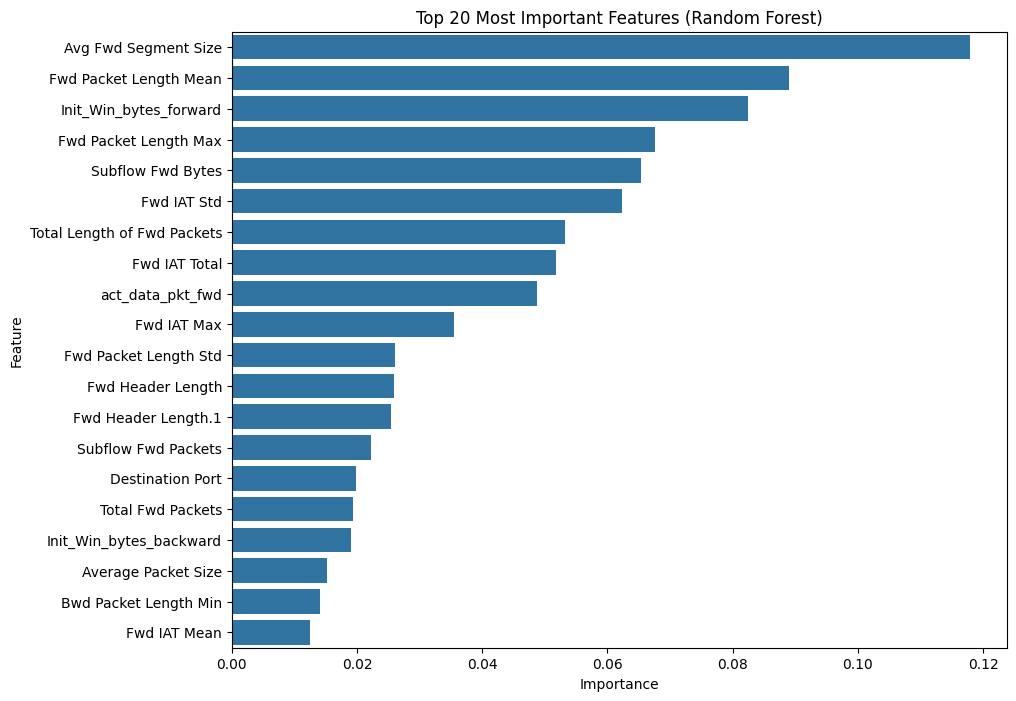

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Drop features with zero variance (constant values)
constant_cols = [col for col in df_dataset.columns if df_dataset[col].nunique() <= 1]
print(f"Dropping {len(constant_cols)} constant columns: {constant_cols}")
df_filtered = df_dataset.drop(columns=constant_cols)

# 2. Separate Features and Target
X = df_filtered.drop('Label', axis=1)
y = df_filtered['Label']

# 3. Split into Train/Test for evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Use Random Forest to get feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 5. Extract and sort importances
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Display Top 20 Features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Most Important Features (Random Forest)')
plt.show()

### Step 5: Feature Selection & Scaling
We will select the top 20 features and apply Standard Scaling, which is essential for Neural Network convergence.

In [ ]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Select Top 20 Features
top_20_features = feature_importance_df.head(20)['Feature'].tolist()
X_train_selected = X_train[top_20_features]
X_test_selected = X_test[top_20_features]

# 2. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print(f"Selected Features: {top_20_features}")

Selected Features: ['Avg Fwd Segment Size', 'Fwd Packet Length Mean', 'Init_Win_bytes_forward', 'Fwd Packet Length Max', 'Subflow Fwd Bytes', 'Fwd IAT Std', 'Total Length of Fwd Packets', 'Fwd IAT Total', 'act_data_pkt_fwd', 'Fwd IAT Max', 'Fwd Packet Length Std', 'Fwd Header Length', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Destination Port', 'Total Fwd Packets', 'Init_Win_bytes_backward', 'Average Packet Size', 'Bwd Packet Length Min', 'Fwd IAT Mean']


### Step 6: Neural Network Training
Defining a simple architecture with Dropout layers to prevent overfitting.

In [ ]:
# 1. Define Model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# 2. Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train
history = model.fit(
    X_train_scaled, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9858 - loss: 0.0555 - val_accuracy: 0.9981 - val_loss: 0.0080
Epoch 2/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9980 - loss: 0.0108 - val_accuracy: 0.9982 - val_loss: 0.0068
Epoch 3/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9983 - loss: 0.0082 - val_accuracy: 0.9984 - val_loss: 0.0062
Epoch 4/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9983 - loss: 0.0076 - val_accuracy: 0.9987 - val_loss: 0.0060
Epoch 5/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9984 - loss: 0.0069 - val_accuracy: 0.9987 - val_loss: 0.0054
Epoch 6/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9985 - loss: 0.0063 - val_accuracy: 0.9987 - val_loss: 0.0052
Epoch 7/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9987 - loss: 0.0055 - val_accuracy: 0.9986 - val_loss: 0.0051
Epoch 8/10
1129/1129 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9987 - loss: 0.0055 - 

### Step 7: Model Evaluation
Checking performance on the test set.

In [ ]:
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9988 - loss: 0.0045
Test Accuracy: 99.88%


### Step 8: Detailed Evaluation
We will use a confusion matrix and a classification report to look at precision and recall for both classes.

1411/1411 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



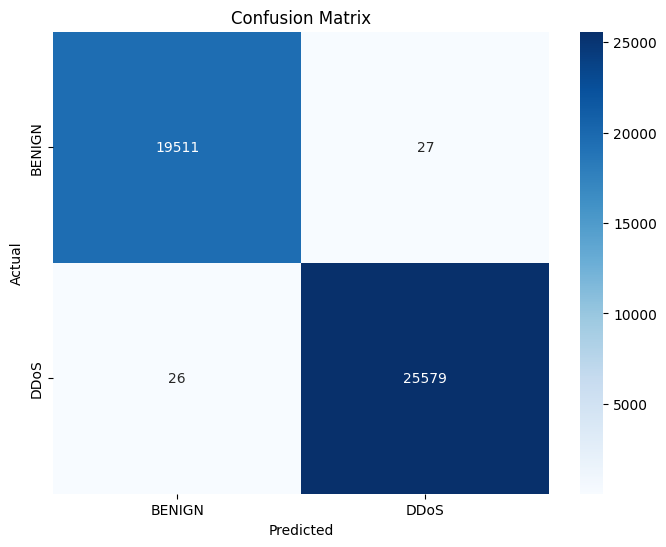

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions (probabilities to binary)
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Step 9: Training History Visualization
We plot the accuracy and loss for both training and validation sets to monitor convergence and check for overfitting.

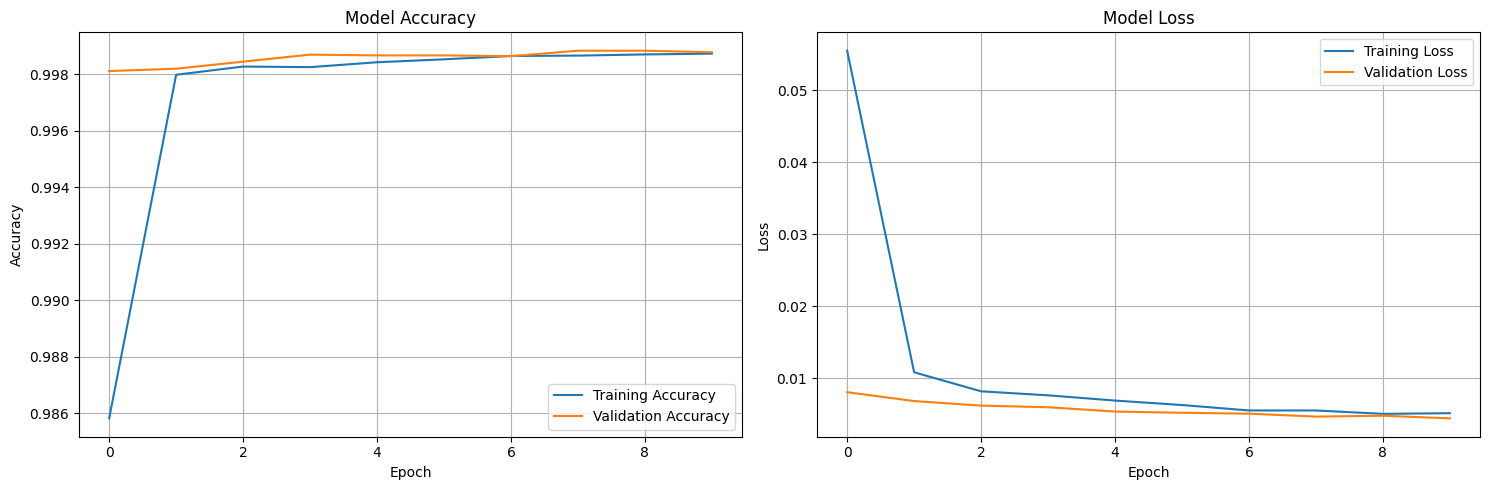

In [ ]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Plot Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# 2. Plot Loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Get the final training accuracy from history
final_train_acc = history.history['accuracy'][-1]

# 2. Get the test accuracy (already calculated in Step 7)
# We'll re-evaluate briefly to ensure we have the scalar variable
_, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)

# 3. Calculate difference
diff = abs(final_train_acc - test_acc)

print(f"Final Training Accuracy: {final_train_acc*100:.4f}%")
print(f"Final Test Accuracy:     {test_acc*100:.4f}%")
print(f"Mathematical Difference: {diff*100:.4f}%")

if diff < 0.01:
    print("\nConclusion: The difference is extremely small (<1%), confirming the model is well-generalized.")
else:
    print("\nConclusion: There is a notable gap, which might suggest minor overfitting or variance.")

Final Training Accuracy: 99.8733%
Final Test Accuracy:     99.8826%
Mathematical Difference: 0.0093%

Conclusion: The difference is extremely small (<1%), confirming the model is well-generalized.


### Step 10: Model Architecture Visualization
We use `plot_model` to create a visual representation of the neural network layers and their connections.

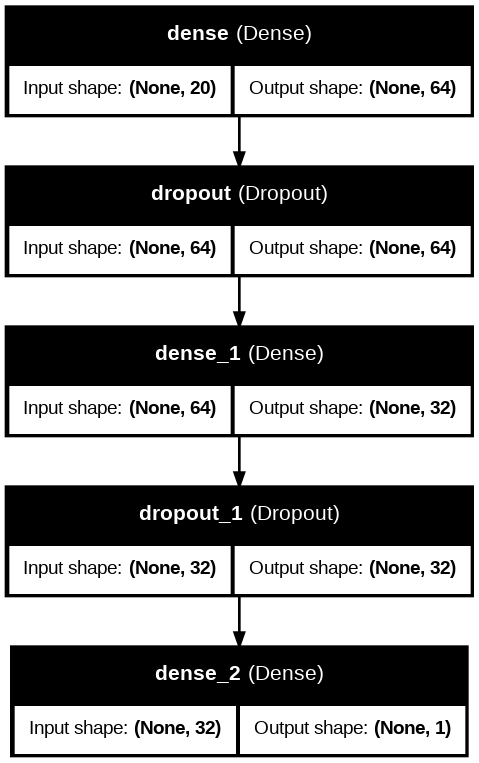

In [ ]:
from tensorflow.keras.utils import plot_model

# Visualize the model architecture
plot_model(
    model,
    to_file='model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=True,
    dpi=96
)

### Step 11: Testing on New Data Subset
We will sample fresh data, apply the same preprocessing/scaling, and run predictions.

In [ ]:
# 1. Sample 100 rows that are not in the existing train or test indices
all_indices = set(df_filtered.index)
used_indices = set(X_train.index) | set(X_test.index)
remaining_indices = list(all_indices - used_indices)

# Sample from remaining if any, otherwise sample from the whole set for demonstration
sample_size = min(100, len(remaining_indices)) if remaining_indices else 100
new_sample = df_filtered.loc[remaining_indices].sample(sample_size, random_state=99) if remaining_indices else df_filtered.sample(100, random_state=99)

# 2. Prepare features and labels
X_new = new_sample[top_20_features]
y_new = new_sample['Label']

# 3. Apply the existing scaler
X_new_scaled = scaler.transform(X_new)

# 4. Run predictions
predictions_prob = model.predict(X_new_scaled, verbose=0)
predictions = (predictions_prob > 0.5).astype(int).flatten()

# 5. Display results comparison
results_df = pd.DataFrame({
    'Actual Label': le.inverse_transform(y_new),
    'Predicted Label': le.inverse_transform(predictions),
    'Confidence': [p[0] if p[0] > 0.5 else 1-p[0] for p in predictions_prob]
})

print(f"Predictions for {sample_size} new samples:")
display(results_df.head(10))

# Calculate accuracy on this specific subset
from sklearn.metrics import accuracy_score
new_acc = accuracy_score(y_new, predictions)
print(f"\nAccuracy on new subset: {new_acc*100:.2f}%")

Predictions for 100 new samples:


,Actual Label,Predicted Label,Confidence
0,DDoS,DDoS,0.999941
1,DDoS,DDoS,1.000000
2,DDoS,DDoS,0.999968
3,DDoS,DDoS,1.000000
4,BENIGN,BENIGN,1.000000
5,DDoS,DDoS,1.000000
6,DDoS,DDoS,1.000000
7,DDoS,DDoS,1.000000
8,BENIGN,BENIGN,0.999101
9,BENIGN,BENIGN,1.000000



Accuracy on new subset: 100.00%


### Step 12: Analyzing Lower Confidence Predictions
We will examine the samples from our fresh subset where the model was not 100% certain about its classification.

In [ ]:
# Filter results where confidence is less than 1.0
lower_confidence_samples = results_df[results_df['Confidence'] < 1.0].sort_values(by='Confidence')

print(f"Found {len(lower_confidence_samples)} samples with confidence < 100%:")
display(lower_confidence_samples)

# If there are samples, let's look at their underlying features
if not lower_confidence_samples.empty:
    low_conf_indices = lower_confidence_samples.index
    display(new_sample.iloc[low_conf_indices][top_20_features].head())
else:
    print("All predictions in this subset were made with essentially 100% confidence.")

Found 43 samples with confidence < 100%:


,Actual Label,Predicted Label,Confidence
74,BENIGN,BENIGN,0.892783
23,BENIGN,BENIGN,0.986000
40,BENIGN,BENIGN,0.993333
47,BENIGN,BENIGN,0.997118
8,BENIGN,BENIGN,0.999101
91,BENIGN,BENIGN,0.999235
28,BENIGN,BENIGN,0.999400
50,BENIGN,BENIGN,0.999445
54,BENIGN,BENIGN,0.999588
51,BENIGN,BENIGN,0.999631


,Avg Fwd Segment Size,Fwd Packet Length Mean,Init_Win_bytes_forward,Fwd Packet Length Max,Subflow Fwd Bytes,Fwd IAT Std,Total Length of Fwd Packets,Fwd IAT Total,act_data_pkt_fwd,Fwd IAT Max,Fwd Packet Length Std,Fwd Header Length,Fwd Header Length.1,Subflow Fwd Packets,Destination Port,Total Fwd Packets,Init_Win_bytes_backward,Average Packet Size,Bwd Packet Length Min,Fwd IAT Mean
1484,6.0,6.0,256,6,12,0.0,12,1550949,1,1550949,0.000000,40,40,2,443,2,-1,9.0,0,1550949.0
139808,0.0,0.0,253,0,0,0.0,0,0,0,0,0.000000,32,32,1,88,1,0,2.4,0,0.0
12980,18.5,18.5,307,37,37,0.0,37,49,0,49,26.162951,64,64,2,465,2,-1,37.0,0,49.0
209791,18.5,18.5,946,31,37,0.0,37,45,1,45,17.677670,40,40,2,9983,2,-1,34.0,0,45.0
18264,6.0,6.0,286,6,6,0.0,6,0,0,0,0.000000,20,20,1,9460,1,256,9.0,6,0.0


### Step 13: Model Persistence
Saving the model and the scaler so they can be reused for future predictions without retraining.

In [ ]:
import pickle

# 1. Save the Keras model using the recommended native format
model.save('ddos_detection_model.keras')

# 2. Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved as 'ddos_detection_model.keras'")
print("Scaler saved as 'scaler.pkl'")

Model saved as 'ddos_detection_model.keras'
Scaler saved as 'scaler.pkl'


### Step 14: Prediction Function
We define a helper function to simplify predicting the nature of incoming network traffic.

In [ ]:
def predict_traffic(input_data):
    """
    Predicts if the input traffic is BENIGN or DDoS.
    input_data: DataFrame or array-like containing the top 20 features.
    """
    # Ensure data is scaled
    scaled_data = scaler.transform(input_data)

    # Get raw probability
    prob = model.predict(scaled_data, verbose=0)

    # Convert to binary label and inverse transform to text
    prediction = (prob > 0.5).astype(int).flatten()
    label = le.inverse_transform(prediction)

    # Calculate confidence percentage
    confidence = [p[0] if p[0] > 0.5 else 1-p[0] for p in prob]

    return label, confidence

# Quick Demo with a sample from the test set
test_sample = X_test_selected.iloc[:5]
labels, confs = predict_traffic(test_sample)

for i in range(len(labels)):
    print(f"Sample {i+1}: Predicted as {labels[i]} with {confs[i]*100:.2f}% confidence.")

Sample 1: Predicted as DDoS with 100.00% confidence.
Sample 2: Predicted as DDoS with 100.00% confidence.
Sample 3: Predicted as BENIGN with 100.00% confidence.
Sample 4: Predicted as BENIGN with 99.98% confidence.
Sample 5: Predicted as DDoS with 100.00% confidence.


### Step 15: Creating a Portable Test Dataset
We will generate a small CSV file containing synthetic samples for the top 20 features so the model can be tested independently.

In [ ]:
import pandas as pd
import numpy as np

# Define the features we need
top_20_features = [
    'Avg Fwd Segment Size', 'Fwd Packet Length Mean', 'Init_Win_bytes_forward',
    'Fwd Packet Length Max', 'Subflow Fwd Bytes', 'Fwd IAT Std',
    'Total Length of Fwd Packets', 'Fwd IAT Total', 'act_data_pkt_fwd',
    'Fwd IAT Max', 'Fwd Packet Length Std', 'Fwd Header Length',
    'Fwd Header Length.1', 'Subflow Fwd Packets', 'Destination Port',
    'Total Fwd Packets', 'Init_Win_bytes_backward', 'Average Packet Size',
    'Bwd Packet Length Min', 'Fwd IAT Mean'
]

# Create 10 synthetic samples (5 Benign-like, 5 DDoS-like based on common patterns)
# Note: These values are simplified representations for testing connectivity
data = {
    'Avg Fwd Segment Size': [6.0, 8.5, 0.0, 450.0, 6.0, 8.0, 1200.0, 6.0, 44.0, 6.0],
    'Fwd Packet Length Mean': [6.0, 8.5, 0.0, 450.0, 6.0, 8.0, 1200.0, 6.0, 44.0, 6.0],
    'Init_Win_bytes_forward': [256, 8192, 229, 256, 8192, 256, 229, 8192, 256, 256],
    'Fwd Packet Length Max': [6, 31, 0, 950, 6, 6, 1460, 6, 51, 6],
    'Subflow Fwd Bytes': [12, 56, 0, 4500, 12, 24, 8400, 12, 132, 12],
    'Fwd IAT Std': [0, 150, 0, 50000, 0, 10, 80000, 0, 400, 0],
    'Total Length of Fwd Packets': [12, 56, 0, 4500, 12, 24, 8400, 12, 132, 12],
    'Fwd IAT Total': [3, 1000, 50, 1000000, 4, 200, 5000000, 3, 5000, 4],
    'act_data_pkt_fwd': [1, 2, 0, 10, 1, 1, 15, 1, 2, 1],
    'Fwd IAT Max': [3, 500, 50, 200000, 4, 150, 1000000, 3, 2000, 4],
    'Fwd Packet Length Std': [0, 5, 0, 100, 0, 0, 200, 0, 10, 0],
    'Fwd Header Length': [40, 64, 40, 320, 40, 40, 480, 40, 64, 40],
    'Fwd Header Length.1': [40, 64, 40, 320, 40, 40, 480, 40, 64, 40],
    'Subflow Fwd Packets': [2, 3, 1, 10, 2, 2, 20, 2, 3, 2],
    'Destination Port': [54865, 80, 53, 80, 443, 80, 80, 22, 53, 80],
    'Total Fwd Packets': [2, 3, 1, 10, 2, 2, 20, 2, 3, 2],
    'Init_Win_bytes_backward': [0, 256, -1, 0, 8192, 0, 256, 0, -1, 0],
    'Average Packet Size': [9.0, 12.0, 0.0, 600.0, 9.0, 10.0, 1500.0, 9.0, 60.0, 9.0],
    'Bwd Packet Length Min': [0, 6, 0, 0, 6, 0, 0, 0, 0, 0],
    'Fwd IAT Mean': [3, 300, 50, 100000, 4, 100, 250000, 3, 1000, 4]
}

custom_test_df = pd.DataFrame(data)
custom_test_df.to_csv('test_samples.csv', index=False)
print("Created 'test_samples.csv' with 10 test records.")

# Demo predicting on this new file
loaded_samples = pd.read_csv('test_samples.csv')
labels, confs = predict_traffic(loaded_samples)

# Display Results
results = pd.DataFrame({'Predicted': labels, 'Confidence': confs})
display(results)

Created 'test_samples.csv' with 10 test records.


,Predicted,Confidence
0,BENIGN,0.999998
1,BENIGN,0.978146
2,BENIGN,0.987264
3,BENIGN,1.000000
4,BENIGN,1.000000
5,BENIGN,0.957889
6,BENIGN,1.000000
7,BENIGN,0.980129
8,BENIGN,0.947490
9,BENIGN,0.955104


### Step 16: Interactive Prediction Tool
This function allows you to paste 20 comma-separated features or input them manually to get a real-time prediction.

In [ ]:
import re

def interactive_prediction():
    print("--- DDoS Detection Manual Input ---")
    print("You can paste the 20 features (separated by commas, tabs, or spaces), or leave it blank for manual mode.")

    raw_input = input("Paste 20 features or press Enter for manual mode: ").strip()

    if raw_input:
        try:
            # Split by comma, tab, or one or more whitespace characters
            split_values = re.split(r'[\t,]|\s+', raw_input)
            # Filter out empty strings that might result from trailing delimiters
            values = [float(x.strip()) for x in split_values if x.strip()]

            if len(values) != 20:
                print(f"Error: Expected 20 values, but detected {len(values)}.")
                return
        except ValueError:
            print("Error: Could not parse input. Ensure all values are numbers.")
            return
    else:
        # Manual mode
        values = []
        for feature in top_20_features:
            while True:
                val = input(f"Enter value for {feature}: ").strip()
                try:
                    values.append(float(val))
                    break
                except ValueError:
                    print("Invalid input. Please enter a numerical value.")

    # Convert to DataFrame to match expected input format of predict_traffic
    input_df = pd.DataFrame([values], columns=top_20_features)

    # Use our existing prediction function
    label, confidence = predict_traffic(input_df)

    print("\n--- Prediction Result ---")
    print(f"Result: {label[0]}")
    print(f"Confidence: {confidence[0]*100:.2f}%")

# Run the tool
interactive_prediction()

--- DDoS Detection Manual Input ---
You can paste the 20 features (separated by commas, tabs, or spaces), or leave it blank for manual mode.
Paste 20 features or press Enter for manual mode: 53	209	2	2	64	258	32	32	32	0	129	129	129	0	1540669.856	19138.75598	69.66666667	115.4743839	203	2	4	4	0	4	4	2	2	0	2	2	0	0	0	0	64	64	9569.37799	9569.37799	32	129	70.8	53.12908808	2822.7	0	0	0	0	0	0	0	0	1	88.5	32	129	0	0	0	0	0	0	2	64	2	258	-1	-1	1	32	0	0	0	0	0	0	0	0
Error: Expected 20 values, but detected 77.
